In [1]:
import os 

In [2]:
os.chdir("..")

In [3]:
%pwd

'c:\\Users\\Asus\\Machine_learning\\LLM\\Language_Model\\GPT_from_scratch'

In [4]:
import os 
import urllib.request 

## Load dataset

In [5]:
URL                 = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
target_directory    = "data"
os.makedirs(target_directory,exist_ok=True)
target_file_path    = os.path.join(target_directory,"gpt_train.txt")

In [6]:
try:
    print("downloading file....")
    urllib.request.urlretrieve(URL,target_file_path)
    print("download completed.")
except Exception as e:
    print(f"Download failed: {e}")
    print(f"Please download the file manually from: {URL}")
    print(f"And upload it to the directory: {target_directory}")
    

downloading file....
download completed.


In [7]:
with open(target_file_path,"r",encoding="utf-8") as file:
    text = file.read()

In [8]:
print(f"length of dataset is ==>> {len(text)}")

length of dataset is ==>> 1115394


In [9]:
## pluck out first 1000 characters from the text file 
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [10]:
# All the unique characters that occur in this text 
chars   = sorted(list(set(text)))
vocab_size  = len(chars)
print("".join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [11]:
## creating mapping from characters to integers 
stoi    = {ch:i for i,ch in enumerate(chars)}
itos    = {i:ch for i,ch in enumerate(chars)}

encode  = lambda word: [stoi[i] for i in word]
decode  = lambda inte: "".join(itos[i] for i in inte)

In [12]:
print(encode("hello world"))
print(decode(encode("hello world")))

[46, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]
hello world


In [13]:
import torch

In [14]:
## Let's encode entire dataset of file. 
data = torch.tensor(encode(text),dtype=torch.long,device="cuda")
print(data.shape,data.type())
print(data[:1000])

torch.Size([1115394]) torch.cuda.LongTensor
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 

In [15]:
## Lets split the data into train and val dataset 
n   = int(0.9 * len(data))
train_data  = data[:n]
val_data    = data[n:]

- We should understand that we dont train the transformers with entire dataset or we never going to feed entire dataset into transformers all at once. That would be computationally expensive.     
- So train with chunks of datasets. 

In [16]:
block_size = 8 
train_data[:block_size]

tensor([18, 47, 56, 57, 58,  1, 15, 47], device='cuda:0')

In [17]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target  = y[t]
    print(f"when input : {context} then target: {target}")

when input : tensor([18], device='cuda:0') then target: 47
when input : tensor([18, 47], device='cuda:0') then target: 56
when input : tensor([18, 47, 56], device='cuda:0') then target: 57
when input : tensor([18, 47, 56, 57], device='cuda:0') then target: 58
when input : tensor([18, 47, 56, 57, 58], device='cuda:0') then target: 1
when input : tensor([18, 47, 56, 57, 58,  1], device='cuda:0') then target: 15
when input : tensor([18, 47, 56, 57, 58,  1, 15], device='cuda:0') then target: 47
when input : tensor([18, 47, 56, 57, 58,  1, 15, 47], device='cuda:0') then target: 58


In [18]:
context.tolist()

[18, 47, 56, 57, 58, 1, 15, 47]

## Batching the data for training 

In [19]:
torch.manual_seed(1337)
batch_size  = 4     # how many independent sequence will we process in parallel 
block_size  = 8     # what is the maximum context for prediction

def get_batch(split):
    data    = train_data if split == "train" else val_data
    ix      = torch.randint(len(data)-block_size,(4,))
    x       = torch.stack([data[i   : i+block_size] for i in ix])
    y       = torch.stack([data[i+1 : i+block_size+1] for i in ix])
    return x,y 

In [20]:
x_batch,y_batch = get_batch("train")
print("input")
print(x_batch.shape)
print(x_batch)
print("targets")
print(y_batch.shape)
print(y_batch)
print("__"*50)
for b in range(batch_size):
    for t in range(block_size):
        context = x_batch[b,:t+1]   # chunks of dataset
        target  = y_batch[b,t]      # next characters in the chunk for the prediction 
        print(f"when input : {context} then target: {target.tolist()}")
        print(f"when input : {decode(context.tolist())} ==>>{decode([target.tolist()])}<<==")
        print("--" * 20)

input
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]], device='cuda:0')
targets
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]], device='cuda:0')
____________________________________________________________________________________________________
when input : tensor([24], device='cuda:0') then target: 43
when input : L ==>>e<<==
----------------------------------------
when input : tensor([24, 43], device='cuda:0') then target: 58
when input : Le ==>>t<<==
----------------------------------------
when input : tensor([24, 43, 58], device='cuda:0') then target: 5
when input : Let ==>>'<<==
----------------------------------------
when input : tensor([24, 43, 58,  5], device='cuda:0') then target: 57
when input : Le

## BiGram Language Model 

In [21]:
import torch 
import torch.nn as nn
import torch.functional as F 
torch.manual_seed(1337);

In [22]:
class BiGramLanguageModel(nn.Module):

    def __init__(self,vocab_size):
        super().__init__()
        # each token directly reads off the logits for next token from a lookup table 
        self.token_embedding_table  = nn.Embedding(vocab_size,vocab_size,device="cuda")
    def forward(self,idx,target=None):
        # index and target are both (B,T) tensor of integers
        logits  = self.token_embedding_table(idx)   # its arrange in the shape of (B,T,C) ==>> (batch,time,channel)
        if target is None:
            loss    = None
        else:    
            B,T,C   = logits.shape
            logits  = logits.view(B*T,C)    # cross entropy input expectation is (minibatch,C)
            target  = target.view(B*T)      
            loss    = nn.functional.cross_entropy(logits,target)
        return logits,loss
    def generate(self,idx,max_new_tokens):
        # idx is (B,T) array of indices in the current context. 
        for _ in range(max_new_tokens):
            logits,loss = self.forward(idx)                         # (B,T,C)
            logits      = logits[:,-1,:]                            # (B,C)
            Probs       = nn.functional.softmax(logits,dim=-1)      # (B,C)
            # sample from the distribution 
            idx_next    = torch.multinomial(Probs,num_samples=1)    # (B,1)
            # append sample index to running sequence 
            idx         = torch.cat([idx,idx_next],dim=1)           # (B,T+1)
        return idx

In [23]:
model  = BiGramLanguageModel(vocab_size).to(device="cuda")
logits,loss = model(x_batch,y_batch)       
print(logits.shape)
print(loss)
print("--"*20)

idx = torch.zeros(1,1,dtype=torch.long,device="cuda")
print(f"prediction : {decode(model.generate(idx,max_new_tokens=100)[0].tolist())}")

torch.Size([32, 65])
tensor(4.8573, device='cuda:0', grad_fn=<NllLossBackward0>)
----------------------------------------
prediction : 
JrTxbDkRZkNwc.wj,ZTxO-On-y$WK
baqPe?kMBFeA$G:XZSGgO-3cjMGd?gLhaGhX'YVX3tpgfNuwq&$WWv.tbaF :X3!FHaGeN


### Embedding Details
- The embedding is defined as a vocab_size * vocab_size matrix.
- When an index number is passed into self.token_embedding_table, it retrieves the corresponding embedding vector from the matrix.

- Example:

    - Consider an embedding matrix of size (65, 65).

    - Given the following tensor input:
```
    a = tensor([
        [43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]
    ])
```
    - Each index in the tensor corresponds to a specific row in the (65, 65) embedding matrix.
    - Consider index 43, then the corresponding embedding is Pluck out from the embedding matrix, 43rd row's of embedding values. 
    - self.token_embedding_table extracts the embeddings for these indices

## Train the Bigram model

In [24]:
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-3)

c:\Users\Asus\anaconda3\envs\llm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
from tqdm import tqdm
import matplotlib.pyplot as plt 

In [ ]:
loss_i      = []
total_steps = 10000

for step in tqdm(range(total_steps), desc="Training Progress", unit="step"):
    x_batch, y_batch    = get_batch("train")   
    logits, loss        = model(x_batch, y_batch)    # Forward pass
    optimizer.zero_grad(set_to_none=True)  # avoid the gradient accumilation and set_to_none=True==> on each step its make to none. 
    loss.backward()                        # Backward pass (compute gradients)
    optimizer.step()                       # responsible for updating the parameters of the model based on the gradients computed during the backward pass 
    loss_i.append(loss.item())             

print(f"Final Loss: {loss.item():.6f}")

Training Progress: 100%|██████████| 10000/10000 [00:14<00:00, 710.17step/s]

Final Loss: 2.495142


In [ ]:
print(f"prediction : {decode(model.generate(idx,max_new_tokens=350)[0].tolist())}")

prediction : 
Fwice my.

HDEdacom orour
Yowhthetof isth ble m W;
I ll, ath iree sengmin lat HFGEdrov ts, anend l nghiriserjbs!
el lind me l.
HAshe ce hiry:
AROKMaisspllw y.
Hllin's n Boopetelivds
MP:
Gll, d mothakleo W-Cou whthCorib3Towie m dourive we hixend t so mower; te

ANk d nthrupt f s ar igis! m:

Thiny aleronth, af Pre?

WASo myr KINLLE!
Kutyb&is:
Sadsal


-  This model is simpler model, because the tokens are not talking to each other. The model is not consider its previous tokens (the model is not considering the context of the text). 
- The model is only considering the last character of prediction  for further prediction. 

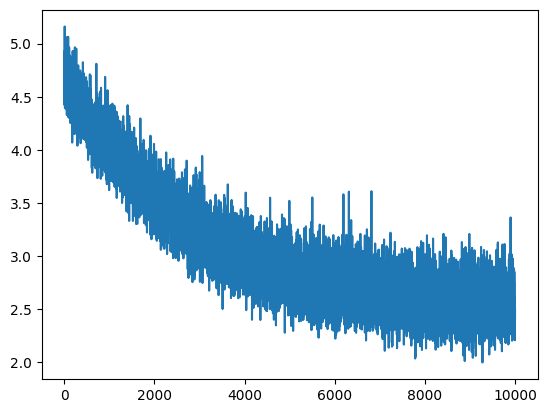

In [ ]:
plt.plot(loss_i);

The above model (Bi gram model), 

## Mathematical Trick of Self-Attention

In [ ]:
import torch as tf     

In [ ]:
# consider a small example 
torch.manual_seed(1337)
B,T,C   = 4,8,2 # batch,time,channel 
x       = tf.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

- From the above case (4,8,2) ==>> (batch,time,channel).The 8 tokens (time) Currently aren't taking to each other, so we need to make talk to each other 
- We want to couple in specific way, 
    - Lets condider a element(token) in 5th position, it should not communicate 6th,7th or future tokens, because those are future tokens.we only want to communicate to 4th,3rd,2nd and 1st tokens, that is the previous (historical tokens). 
    - The information only flows from previous context to current time stamp (current tokens).
    - we cannot get any information from future, because we are trying to predict the future. 
- Consider 5th token and if it like to communicate to previous token, the most simple method is 
### Method 1: Average of preceding Elements 
- Add the average of preceding elements
    - Avg_4 = (E1+E2+E3+E4)/4, 
    - E5    = E5 + Avg_4 
- But This method is really weak form interaction (communication). By doing this method we los tons of information of previous context. 


In [ ]:
## Inefficient method 
x_bow = tf.zeros((B,T,C)) # x_bow = bag of words 
for b in range(B):
    for t in range(T):
        x_prev      = x[b,:t+1]             # x_prev.shape ==>> (t,c)
        x_bow[b,t]  = torch.mean(x_prev,0)  # averging on dim=0

- this above method is really inefficient method, we can do this by another efficent method by matrix multiplication method. 

In [ ]:
x[0],x_bow[0]

(tensor([[ 0.1808, -0.0700],
         [-0.3596, -0.9152],
         [ 0.6258,  0.0255],
         [ 0.9545,  0.0643],
         [ 0.3612,  1.1679],
         [-1.3499, -0.5102],
         [ 0.2360, -0.2398],
         [-0.9211,  1.5433]]),
 tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]))

- Lets consider the first batch of x and x_bow. x is the orignal matrix and x-bow is the sum of average of previous elements. 
- conder 
    - x[0][0]     = [0.1808,-0.0700] and
    - x_bow[0][0] = [0.1808,-0.0700] 
        - In this case both are same, thast because we are doing avg of just one token 
        - x_prev = x[0, :0+1] selects rows 0 up to (but not including) 1 -> tensor([[ 0.1808, -0.0700]]) (shape (1, 2))
        - x_bow[0, 0] = torch.mean(x_prev, 0) averages along the first dimension (the time dimension here).
        - x_bow[0, 0] = tensor([ 0.1808, -0.0700])
- consider 2 nd element 
    - x[0][1]     = [[0.1808,-0.0700],
                     [-0.3596,-0.9152]] and
    - x_bow[0][1] = [[0.1808,-0.0700],
                     [-0.0894,-0.4926]] 
        - In this case, x_bow the second elements are the average of its previous elements. That how its working here. 
        - x_prev = x[0, :1+1] selects rows 0 and 1 -> tensor([[ 0.1808, -0.0700], [-0.3596, -0.9152]]) (shape (2, 2))
        - x_bow[0, 1] = torch.mean(x_prev, 0)
        - x_bow[0, 1] = tensor([(0.1808 + (-0.3596))/2, (-0.0700 + (-0.9152))/2])
        - x_bow[0, 1] = tensor([-0.1788 / 2, -0.9852 / 2])
        - x_bow[0, 1] = tensor([-0.0894, -0.4926])
          

In [ ]:
torch.triu(torch.ones(3,3))

tensor([[1., 1., 1.],
        [0., 1., 1.],
        [0., 0., 1.]])

In [ ]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))
a = a / tf.sum(a,dim=1,keepdim=True) # for keeping the dim of matrix constant 
b = torch.randint(0,10,size=(3,2)).float()
c = a @ b 
print("a=")
print(a) 
print("--"*20)
print("b=")
print(b) 
print("--"*20)
print("c=")
print(c) 
print("--"*20)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
----------------------------------------
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
----------------------------------------
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])
----------------------------------------


- By this method, get the average of previous elemets. from C, in 2nd element which is average of 1st and second elements. 
- 3 element is average of 1st 2nd and 3rd elements. 

## Lets create Average of preceding Elements with matrics multiplication

In [31]:
## efficent method 
wei     = tf.tril(tf.ones(T,T)) # T is value from B,T,C 
wei     = wei / wei.sum(1,keepdim=True) # shape ==>> (T,T) 
x_bow2  = wei @ x       # (8,8) and (4,8,2), by doing broadcasting it would becomes   (4,8,8) @ (4,8,2) ==>> (4,8,2)
                                                                                    # (B,T,T) @ (B,T,C) ==>> (B,T,C)
# lets check the x_bow and x_bow2 are identical or not 
tf.allclose(x_bow,x_bow2)

False

In [ ]:
x_bow2[1]

tensor([[ 1.3488, -0.1396],
        [ 0.8173,  0.4127],
        [-0.1342,  0.4395],
        [ 0.2711,  0.4774],
        [ 0.2421,  0.0694],
        [ 0.0084,  0.0020],
        [ 0.0712, -0.1128],
        [ 0.2527,  0.2149]])

In [ ]:
x_bow[1]

tensor([[ 1.3488, -0.1396],
        [ 0.8173,  0.4127],
        [-0.1342,  0.4395],
        [ 0.2711,  0.4774],
        [ 0.2421,  0.0694],
        [ 0.0084,  0.0020],
        [ 0.0712, -0.1128],
        [ 0.2527,  0.2149]])

In [ ]:
tf.allclose(x_bow[3],x_bow2[3])

True